# M3 data audit — SCKN × NKC field coverage & ISBN intersection

Answers three questions before M4 (matching spike):

1. **SCKN** — unique ISBNs, missing ISBNs, bestseller-frequency distribution
2. **NKC** — ISBN / OCLC / original-title coverage overall and broken down by source language
3. **Intersection** — how many SCKN ISBNs land in NKC, and what falls out

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCKN_PATH = REPO / "data" / "raw" / "sckn_charts.csv"
NKC_PATH  = REPO / "data" / "interim" / "nkc_translations.csv"

sys.path.insert(0, str(REPO / "src" / "data"))
from text_utils import norm_isbn

sckn = pd.read_csv(SCKN_PATH, dtype=str).fillna("")
nkc  = pd.read_csv(NKC_PATH,  dtype=str).fillna("")

print(f"SCKN rows : {len(sckn):>8,}")
print(f"NKC rows  : {len(nkc):>8,}")

SCKN rows :   36,080
NKC rows  :  225,483


---
## 1  SCKN audit

In [3]:
sckn_has_isbn = sckn["isbn"].str.strip() != ""
n_total       = len(sckn)
n_with_isbn   = sckn_has_isbn.sum()
n_missing_isbn = n_total - n_with_isbn

print("=== SCKN ISBN presence ===")
print(f"Total chart entries   : {n_total:>7,}")
print(f"With ISBN             : {n_with_isbn:>7,}  ({n_with_isbn/n_total:.4%})")
print(f"Missing ISBN          : {n_missing_isbn:>7,}  ({n_missing_isbn/n_total:.4%})")

sckn_isbns = sckn.loc[sckn_has_isbn, "isbn"].str.strip().str.upper()
n_unique = sckn_isbns.nunique()
print(f"\nUnique ISBNs (raw)    : {n_unique:>7,}")

=== SCKN ISBN presence ===
Total chart entries   :  36,080
With ISBN             :  36,066  (99.9612%)
Missing ISBN          :      14  (0.0388%)

Unique ISBNs (raw)    :   8,379


In [4]:
appearances = (
    sckn[sckn_has_isbn]
    .assign(isbn_norm=sckn.loc[sckn_has_isbn, "isbn"].str.strip().str.upper())
    .groupby("isbn_norm")
    .size()
    .rename("chart_appearances")
)

freq_dist = appearances.value_counts().sort_index()

print("=== Bestseller frequency distribution ===")
print("appearances  |  #ISBNs  |  % of unique ISBNs")
print("-" * 44)
for k, v in freq_dist.items():
    pct = v / n_unique
    tag = " ← 1×" if k == 1 else (" ← 2×" if k == 2 else "")
    if k <= 10 or k > freq_dist.index.max() - 3:
        print(f"  {k:>4}          {v:>6,}     {pct:>6.3%}{tag}")
    elif k == 11:
        print("   ...")

print(f"\nMedian appearances : {appearances.median():.0f}")
print(f"Max appearances    : {appearances.max()}  (isbn={appearances.idxmax()})")

=== Bestseller frequency distribution ===
appearances  |  #ISBNs  |  % of unique ISBNs
--------------------------------------------
     1           3,884     46.354% ← 1×
     2           1,291     15.408% ← 2×
     3             733     8.748%
     4             486     5.800%
     5             330     3.938%
     6             272     3.246%
     7             213     2.542%
     8             168     2.005%
     9             142     1.695%
    10             121     1.444%
   ...
   257               1     0.012%

Median appearances : 2
Max appearances    : 257  (isbn=978-80-00-02225-3)


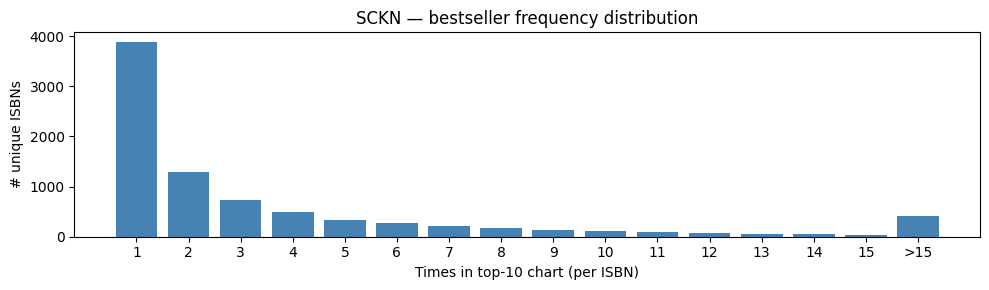

In [5]:
cap = 15
plot_data = freq_dist[freq_dist.index <= cap]
rest = freq_dist[freq_dist.index > cap].sum()

labels = [str(k) for k in plot_data.index] + ([f">{cap}"] if rest else [])
values = list(plot_data.values) + ([rest] if rest else [])

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(labels, values, color="steelblue")
ax.set_xlabel("Times in top-10 chart (per ISBN)")
ax.set_ylabel("# unique ISBNs")
ax.set_title("SCKN — bestseller frequency distribution")
plt.tight_layout()
plt.show()

---
## 2  NKC field coverage

In [6]:
def coverage(series, label):
    n = (series.str.strip() != "").sum()
    return {"field": label, "present": n, "missing": len(series) - n, "coverage": n / len(series)}

rows = [
    coverage(nkc["czech_isbn"],     "ISBN (020 $a)"),
    coverage(nkc["oclc"],           "OCLC (035 $a)"),
    coverage(nkc["original_title"], "Original title (240 $a)"),
    coverage(nkc["author"],         "Author (100 $a)"),
    coverage(nkc["czech_pub_year"], "Czech pub year"),
    coverage(nkc["genres"],         "Genre (655 $a)"),
]

cov = pd.DataFrame(rows).set_index("field")
print("=== NKC field coverage (all 225 k translations) ===")
print(cov.to_string(formatters={"present": "{:,}".format, "missing": "{:,}".format, "coverage": "{:.1%}".format}))

=== NKC field coverage (all 225 k translations) ===
                        present missing coverage
field                                           
ISBN (020 $a)           153,340  72,143    68.0%
OCLC (035 $a)           207,320  18,163    91.9%
Original title (240 $a) 140,679  84,804    62.4%
Author (100 $a)         199,094  26,389    88.3%
Czech pub year          216,676   8,807    96.1%
Genre (655 $a)          183,200  42,283    81.2%


In [7]:
top_langs = nkc["source_lang"].value_counts().head(15).index.tolist()

rows_lang = []
for lang in top_langs:
    sub = nkc[nkc["source_lang"] == lang]
    rows_lang.append({
        "source_lang":    lang,
        "n_records":      len(sub),
        "isbn_cov":       (sub["czech_isbn"].str.strip()    != "").sum() / len(sub),
        "oclc_cov":       (sub["oclc"].str.strip()          != "").sum() / len(sub),
        "orig_title_cov": (sub["original_title"].str.strip() != "").sum() / len(sub),
    })

lang_df = pd.DataFrame(rows_lang).set_index("source_lang")
print("=== NKC coverage by source language (top 15) ===")
print(
    lang_df.to_string(
        formatters={
            "n_records":      "{:>7,}".format,
            "isbn_cov":       "{:.1%}".format,
            "oclc_cov":       "{:.1%}".format,
            "orig_title_cov": "{:.1%}".format,
        }
    )
)

=== NKC coverage by source language (top 15) ===
            n_records isbn_cov oclc_cov orig_title_cov
source_lang                                           
eng            95,945    87.4%    94.8%          79.7%
ger            48,248    74.2%    91.9%          51.8%
rus            21,386    10.2%    91.0%          40.6%
fre            18,658    50.3%    85.4%          59.2%
pol             5,086    47.1%    84.8%          48.2%
slo             4,727    50.3%    89.2%          40.0%
ita             4,556    61.7%    88.4%          58.9%
spa             3,622    77.1%    93.8%          67.5%
lat             2,057    39.6%    83.3%          35.7%
mul             1,906    29.7%    94.0%           0.8%
swe             1,868    70.3%    91.5%          75.6%
hun             1,233    29.0%    87.7%          51.4%
dut             1,161    71.0%    95.0%          68.2%
nor             1,068    53.8%    89.3%          70.3%
dan               884    41.4%    87.1%          49.4%


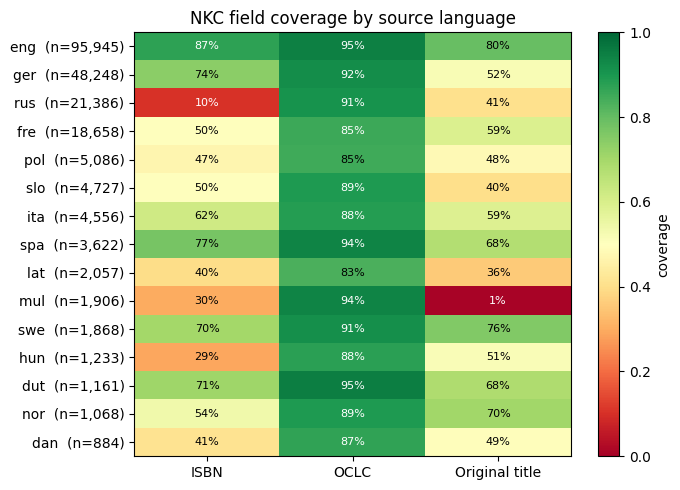

In [8]:
import numpy as np

heat_cols   = ["isbn_cov", "oclc_cov", "orig_title_cov"]
heat_labels = ["ISBN", "OCLC", "Original title"]
mat = lang_df[heat_cols].values

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="coverage")
ax.set_xticks(range(len(heat_labels)))
ax.set_xticklabels(heat_labels)
ax.set_yticks(range(len(lang_df)))
ax.set_yticklabels([f"{lang}  (n={lang_df.loc[lang,'n_records']:,})" for lang in lang_df.index])
ax.set_title("NKC field coverage by source language")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.0%}", ha="center", va="center", fontsize=8,
                color="black" if 0.25 < mat[i, j] < 0.85 else "white")
plt.tight_layout()
plt.show()

---
## 3  Intersection SCKN ↔ NKC via ISBN

Normalisation via `norm_isbn` from `src/data/text_utils.py` (shared with the full pipeline):
ISBN-10 → converted to ISBN-13 via EAN-13 formula; 12-digit strings → leading `9` prepended;
dashes/spaces stripped, uppercased. NKC pipe-separated multi-ISBN values are exploded before
normalising so each variant becomes a separate lookup key.

In [9]:
# SCKN side
sckn_with = sckn[sckn_has_isbn].copy()
sckn_with["isbn_norm"] = sckn_with["isbn"].apply(norm_isbn)
sckn_unique_norm = sckn_with["isbn_norm"].unique()

# NKC side — explode pipe-separated multi-ISBN values before normalising
nkc_isbn_raw = nkc[nkc["czech_isbn"].str.strip() != ""][["nkc_id", "czech_isbn"]].copy()
nkc_isbn_exploded = (
    nkc_isbn_raw
    .assign(isbn_part=nkc_isbn_raw["czech_isbn"].str.split("|"))
    .explode("isbn_part")
)
nkc_isbn_exploded["isbn_norm"] = nkc_isbn_exploded["isbn_part"].apply(norm_isbn)
nkc_isbn_set = set(nkc_isbn_exploded["isbn_norm"].str.strip())
nkc_isbn_set.discard("")

print(f"SCKN unique normalised ISBNs : {len(sckn_unique_norm):>6,}")
print(f"NKC  unique normalised ISBNs : {len(nkc_isbn_set):>6,}")

SCKN unique normalised ISBNs :  8,174
NKC  unique normalised ISBNs : 159,618


In [10]:
def in_nkc(isbn: str) -> bool:
    if isbn in nkc_isbn_set:
        return True
    # 12-digit strings: try prepending 9 (SCKN sometimes drops leading digit of ISBN-13)
    if len(isbn) == 12 and isbn.isdigit():
        return ("9" + isbn) in nkc_isbn_set
    return False

sckn_norm_series = pd.Series(sckn_unique_norm)
found_mask = sckn_norm_series.apply(in_nkc)
found  = sckn_norm_series[found_mask]
missed = sckn_norm_series[~found_mask]

n_found  = len(found)
n_missed = len(missed)
n_sckn   = len(sckn_unique_norm)

print("=== SCKN → NKC ISBN match ===")
print(f"SCKN unique ISBNs (normalised) : {n_sckn:>6,}")
print(f"  Found in NKC                 : {n_found:>6,}  ({n_found/n_sckn:.1%})")
print(f"  Not found in NKC             : {n_missed:>6,}  ({n_missed/n_sckn:.1%})")

=== SCKN → NKC ISBN match ===
SCKN unique ISBNs (normalised) :  8,174
  Found in NKC                 :  3,397  (41.6%)
  Not found in NKC             :  4,777  (58.4%)


In [11]:
# Diagnose the misses
sckn_missed_rows = sckn_with[sckn_with["isbn_norm"].isin(missed)]

print(f"SCKN chart entries behind missed ISBNs: {len(sckn_missed_rows):,}")
print()

print("=== Missed ISBNs — category breakdown ===")
miss_by_cat = (
    sckn_missed_rows.drop_duplicates("isbn_norm")
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)
print(miss_by_cat.to_string())
print()

print("=== Missed ISBNs — by year (first appearance) ===")
miss_first_year = (
    sckn_missed_rows
    .assign(year=sckn_missed_rows["year"].astype(int))
    .groupby("isbn_norm")["year"].min().reset_index()
    .groupby("year").size().rename("missed_isbns")
)
found_first_year = (
    sckn_with[sckn_with["isbn_norm"].isin(found)]
    .assign(year=sckn_with["year"].astype(int))
    .groupby("isbn_norm")["year"].min().reset_index()
    .groupby("year").size().rename("found_isbns")
)
year_compare = pd.concat([found_first_year, miss_first_year], axis=1).fillna(0).astype(int)
year_compare["miss_rate"] = year_compare["missed_isbns"] / (
    year_compare["found_isbns"] + year_compare["missed_isbns"]
)
print(year_compare.to_string(formatters={"miss_rate": "{:.0%}".format}))

SCKN chart entries behind missed ISBNs: 20,609

=== Missed ISBNs — category breakdown ===
category
naučná literatura               2232
literatura pro děti a mládež    1444
beletrie                        1101

=== Missed ISBNs — by year (first appearance) ===
      found_isbns  missed_isbns miss_rate
year                                     
2003          215           348       62%
2004          239           342       59%
2005          130           270       68%
2006          143           207       59%
2007          122           409       77%
2008          149           244       62%
2009          155           244       61%
2010          181           274       60%
2011          169           240       59%
2012          151           205       58%
2013          152           215       59%
2014          148           220       60%
2015          195           220       53%
2016          171           228       57%
2017          162           184       53%
2018          100        

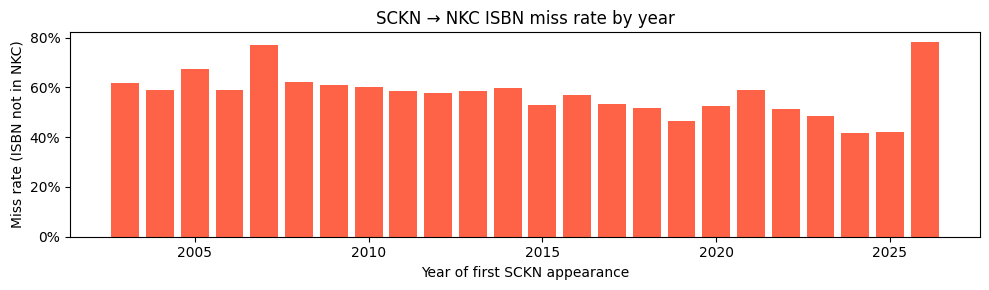

In [12]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(year_compare.index, year_compare["miss_rate"], color="tomato")
ax.set_xlabel("Year of first SCKN appearance")
ax.set_ylabel("Miss rate (ISBN not in NKC)")
ax.set_title("SCKN → NKC ISBN miss rate by year")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

In [13]:
print("=== Sample of 20 missed SCKN ISBNs ===")
sample_cols = ["year", "week", "category", "rank", "isbn", "author", "title"]
print(
    sckn_missed_rows
    .drop_duplicates("isbn_norm")
    .sort_values(["year", "week"])
    .head(20)[sample_cols]
    .to_string(index=False)
)

=== Sample of 20 missed SCKN ISBNs ===
year week                     category rank          isbn                              author                                          title
2003    1                     beletrie    1 80-86718-00-X  Růžičková Helena, Formáčková Marie                     Deník mezi životem a smrtí
2003    1                     beletrie    2 80-86631-02-8                      Sommerová Olga                               O čem sní ženy 2
2003    1                     beletrie    3 80-238-5878-5                    Růžičková Helena                         A tak jsem šla životem
2003    1                     beletrie    4 80-200-1023-8                       Branald Adolf                            Převleky mého města
2003    1            naučná literatura    2 80-238-8971-0                    Hora-Hořejš Petr                      Toulky českou minulostí 9
2003    1            naučná literatura    3 80-86394-85-9                                                          